# Experiment 2 - CDC BRFSS

Class imbalance handling on the CDC BRFSS dataset.

This experiment compares three training strategies:

1. **No Resampling** - raw imbalanced training data  
2. **SMOTE** - synthetic oversampling on the training set only  
3. **Class Weighting** - model gives more importance to the minority class  

Models:
- Logistic Regression
- LightGBM
- XGBoost

Main focus:
- F1 Score
- Recall



In [ ]:
#1 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

from IPython.display import display

print("imports successfully loaded")

imports successfully loaded


In [ ]:
#2 Clone repo / move into project folder
if not os.path.exists("/content/Predicting-Type-2-Diabetes"):
    !git clone https://github.com/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes.git

%cd /content/Predicting-Type-2-Diabetes

Cloning into 'Predicting-Type-2-Diabetes'...
remote: Enumerating objects: 478, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 478 (delta 79), reused 37 (delta 31), pack-reused 328 (from 1)
Receiving objects: 100% (478/478), 10.42 MiB | 12.10 MiB/s, done.
Resolving deltas: 100% (209/209), done.
/content/Predicting-Type-2-Diabetes


In [ ]:
#3 Load CDC BRFSS data and create train/test split
path = "data/raw/diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(path)

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("-" * 50)
print(" Experiment 2: CDC Class Imbalance Handling")
print("-" * 50)
print(f"Dataset shape: {df.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("\nOriginal target balance (%):")
print((y.value_counts(normalize=True) * 100).round(2))

--------------------------------------------------
 Experiment 2: CDC Class Imbalance Handling
--------------------------------------------------
Dataset shape: (253680, 22)
X_train shape: (202944, 21)
X_test shape: (50736, 21)

Original target balance (%):
Diabetes_binary
0.0    86.07
1.0    13.93
Name: proportion, dtype: float64


In [4]:
#4 Prepare scaled data and SMOTE data

# scaling is used for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE for tree-based models on raw train data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# SMOTE for Logistic Regression on scaled train data
X_train_scaled_smote, y_train_scaled_smote = smote.fit_resample(X_train_scaled, y_train)

# class ratio for XGBoost class weighting
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print(f"\nXGBoost scale_pos_weight: {scale_pos_weight:.2f}")

Before SMOTE:
Diabetes_binary
0.0    174667
1.0     28277
Name: count, dtype: int64

After SMOTE:
Diabetes_binary
0.0    174667
1.0    174667
Name: count, dtype: int64

XGBoost scale_pos_weight: 6.18


In [5]:
#5 Evaluation helper function
def evaluate_model(strategy, model_name, model, X_eval, y_true):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    return {
        "Strategy": strategy,
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_true, y_prob),
        "y_pred": y_pred,
        "y_prob": y_prob
    }

all_results = []
all_predictions = {}

print("evaluation helper ready")

evaluation helper ready


In [6]:
#6 Strategy 1: no resampling
print("-" * 50)
print(" Strategy 1: No Resampling")
print("-" * 50)

lr_raw = LogisticRegression(max_iter=1000, random_state=42)
lr_raw.fit(X_train_scaled, y_train)

lgbm_raw = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm_raw.fit(X_train, y_train)

xgb_raw = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_raw.fit(X_train, y_train)

raw_models = {
    "Logistic Regression": (lr_raw, X_test_scaled),
    "LightGBM": (lgbm_raw, X_test),
    "XGBoost": (xgb_raw, X_test)
}

for name, (model, X_eval) in raw_models.items():
    result = evaluate_model("No Resampling", name, model, X_eval, y_test)
    all_predictions[("No Resampling", name)] = result
    all_results.append({k: v for k, v in result.items() if k not in ["y_pred", "y_prob"]})
    print(f"  {name} — done")

print("\nNo resampling models trained successfully.")

--------------------------------------------------
 Strategy 1: No Resampling
--------------------------------------------------
  Logistic Regression — done
  LightGBM — done
  XGBoost — done

No resampling models trained successfully.


In [7]:
#7 Strategy 2: SMOTE
print("-" * 50)
print(" Strategy 2: SMOTE")
print("-" * 50)

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_scaled_smote, y_train_scaled_smote)

lgbm_smote = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm_smote.fit(X_train_smote, y_train_smote)

xgb_smote = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_smote.fit(X_train_smote, y_train_smote)

smote_models = {
    "Logistic Regression": (lr_smote, X_test_scaled),
    "LightGBM": (lgbm_smote, X_test),
    "XGBoost": (xgb_smote, X_test)
}

for name, (model, X_eval) in smote_models.items():
    result = evaluate_model("SMOTE", name, model, X_eval, y_test)
    all_predictions[("SMOTE", name)] = result
    all_results.append({k: v for k, v in result.items() if k not in ["y_pred", "y_prob"]})
    print(f"  {name} — done")

print("\nSMOTE models trained successfully.")

--------------------------------------------------
 Strategy 2: SMOTE
--------------------------------------------------
  Logistic Regression — done
  LightGBM — done
  XGBoost — done

SMOTE models trained successfully.


In [8]:
#8 Strategy 3: class weighting
print("-" * 50)
print(" Strategy 3: Class Weighting")
print("-" * 50)

lr_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_weighted.fit(X_train_scaled, y_train)

lgbm_weighted = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbosity=-1,
    class_weight="balanced"
)
lgbm_weighted.fit(X_train, y_train)

xgb_weighted = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)
xgb_weighted.fit(X_train, y_train)

weighted_models = {
    "Logistic Regression": (lr_weighted, X_test_scaled),
    "LightGBM": (lgbm_weighted, X_test),
    "XGBoost": (xgb_weighted, X_test)
}

for name, (model, X_eval) in weighted_models.items():
    result = evaluate_model("Class Weighting", name, model, X_eval, y_test)
    all_predictions[("Class Weighting", name)] = result
    all_results.append({k: v for k, v in result.items() if k not in ["y_pred", "y_prob"]})
    print(f"  {name} — done")

print("\nClass weighted models trained successfully.")

--------------------------------------------------
 Strategy 3: Class Weighting
--------------------------------------------------
  Logistic Regression — done
  LightGBM — done
  XGBoost — done

Class weighted models trained successfully.


In [9]:
#9 Comparative results table
results_df = pd.DataFrame(all_results)

print("-" * 70)
print(" Experiment 2 - CDC Imbalance Strategy Comparison")
print("-" * 70)

display(results_df.round(4).sort_values(by=["F1 Score", "Recall"], ascending=False))

----------------------------------------------------------------------
 Experiment 2 - CDC Imbalance Strategy Comparison
----------------------------------------------------------------------


,Strategy,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
3,SMOTE,Logistic Regression,0.7331,0.3122,0.7614,0.4429,0.8188
8,Class Weighting,XGBoost,0.7284,0.3100,0.7745,0.4428,0.8218
6,Class Weighting,Logistic Regression,0.7315,0.3107,0.7611,0.4413,0.8196
7,Class Weighting,LightGBM,0.7203,0.3056,0.7915,0.4409,0.8267
4,SMOTE,LightGBM,0.8630,0.5212,0.2067,0.2960,0.8235
5,SMOTE,XGBoost,0.8640,0.5342,0.1856,0.2755,0.8231
1,No Resampling,LightGBM,0.8655,0.5591,0.1640,0.2536,0.8269
2,No Resampling,XGBoost,0.8634,0.5309,0.1665,0.2535,0.8237
0,No Resampling,Logistic Regression,0.8621,0.5171,0.1583,0.2424,0.8192


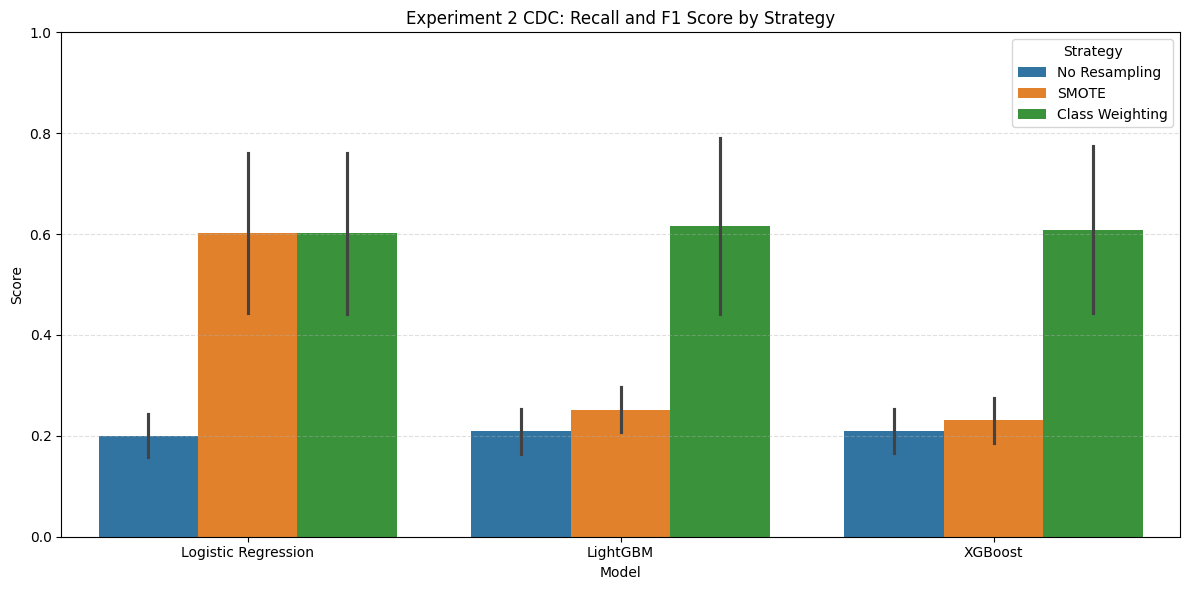

In [10]:
#10 Compare recall and F1 score
plot_df = results_df.melt(
    id_vars=["Strategy", "Model"],
    value_vars=["Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Strategy")
plt.title("Experiment 2 CDC: Recall and F1 Score by Strategy")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()